libraries and dependencies

In [5]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
t, V, alpha, gamma, Q, delta_T, delta_e = np.loadtxt(
    'flight_data.txt', 
    unpack=True
)
# --- 1. Physics Constants ---
g = 9.8; rho = 1.225; S = 0.25; cbar = 0.2; m = 1.2; Jy = 0.05

def run_oem_identification(t, V_m, alpha_deg, gamma_deg, Q_deg, delta_T, delta_e_deg, theta_init):
    # PRE-PROCESS: All angular data MUST be in Radians for the physics equations
    alpha_m = np.radians(alpha_deg)
    gamma_m = np.radians(gamma_deg)
    Q_m     = np.radians(Q_deg)
    de_rad  = np.radians(delta_e_deg)
    
    # Pack measured states for comparison (Shape: 4 x N)
    measured = np.vstack([V_m, alpha_m, gamma_m, Q_m])
    
    # WEIGHTING: Normalize errors by standard deviation 
    # (Prevents the high magnitude of V from drowning out the angles)
    weights = 1.0 / np.std(measured, axis=1)

    def ode_dynamics(t_curr, x, params):
        V, a, g_ang, Q = x
        CL0, CLa, CD0, kCD, CM0, CMa, CMQ, CMe = params
        
        # Interpolate inputs at current time
        T  = np.interp(t_curr, t, delta_T)
        de = np.interp(t_curr, t, de_rad)

        q_dyn = 0.5 * rho * max(V, 0.1)**2
        
        # Aero Model (Calculated in Radians)
        CL = CL0 + CLa * a
        CD = CD0 + kCD * CL**2
        qhat = (cbar * Q) / (2 * max(V, 0.1))
        CM = CM0 + CMa * a + CMQ * qhat + CMe * de

        L, D, M = q_dyn * S * CL, q_dyn * S * CD, q_dyn * S * cbar * CM

        # Equations of Motion
        Vdot     = (-D + T*np.cos(a) - m*9.8*np.sin(g_ang)) / m
        gammadot = (L + T*np.sin(a) - m*9.8*np.cos(g_ang)) / (m * max(V, 0.1))
        Qdot     = M / Jy
        alphadot = Q - gammadot
        
        return [Vdot, alphadot, gammadot, Qdot]

    def residuals(params):
        # Integrate from initial measured state
        sol = solve_ivp(
            ode_dynamics, [t[0], t[-1]], measured[:, 0], 
            t_eval=t, args=(params,), method='RK45'
        )
        
        if not sol.success: return np.ones(measured.size) * 1e6
            
        # Compute normalized error (Residuals)
        err = (sol.y - measured)
        for i in range(4):
            err[i, :] *= weights[i]
            
        return err.flatten()

    # 2. RUN OPTIMIZATION
    res = least_squares(
        residuals, theta_init,
        bounds=([0.1, 3.0, 0.02, 0.05, -0.05, -1.0, -15.0, -2.0], 
                [0.3, 6.0, 0.06, 0.15,  0.05, -0.1, -2.0,  -0.5]),
        verbose=1
    )
    return res.x

# --- 3. Execution & Reporting ---
theta_init = [0.25, 4.0, 0.05, 0.1, 0.03, -0.4, -5.0, -1.0]
params_true = [0.20, 4.50, 0.04, 0.08, 0.02, -0.50, -8.0, -1.0]
labels = ["CL0", "CL_alpha", "CD0", "k_CD", "CM0", "CM_alpha", "CM_Q", "CM_e"]

estimated = run_oem_identification(t, V, alpha, gamma, Q, delta_T, delta_e, theta_init)

print(f"{'Param':<10} | {'True':<8} | {'Estimated':<10} | {'% Error'}")
print("-" * 50)
for l, t_val, e_val in zip(labels, params_true, estimated):
    err = abs((e_val - t_val) / t_val) * 100
    print(f"{l:<10} | {t_val:<8.3f} | {e_val:<10.3f} | {err:.1f}%")

`xtol` termination condition is satisfied.
Function evaluations 14, initial cost 1.1125e+07, final cost 2.1138e+06, first-order optimality 5.10e+09.
Param      | True     | Estimated  | % Error
--------------------------------------------------
CL0        | 0.200    | 0.174      | 12.9%
CL_alpha   | 4.500    | 3.213      | 28.6%
CD0        | 0.040    | 0.038      | 5.6%
k_CD       | 0.080    | 0.050      | 36.9%
CM0        | 0.020    | 0.009      | 57.1%
CM_alpha   | -0.500   | -0.657     | 31.4%
CM_Q       | -8.000   | -2.199     | 72.5%
CM_e       | -1.000   | -1.005     | 0.5%


get data

trim

FRF composition

In [80]:
f_lo, f_hi = 0.05, 5.0
band = (freqs > f_lo) & (freqs <= f_hi)

# ── Regressor helper ───────────────────────────────────────────────────
def complex_to_real(A, b):
    return np.vstack([A.real, A.imag]), np.concatenate([b.real, b.imag])

def solve(Phi_cols_time, b_time):
    """FFT columns, column-scale for conditioning, then least squares."""
    Phi_f = np.column_stack([F(col)[band] for col in Phi_cols_time])
    b_f   = F(b_time)[band]
    A, y  = complex_to_real(Phi_f, b_f)
    
    # Column scale: divide each column by its norm, solve, then undo
    col_norms = np.linalg.norm(A, axis=0)
    col_norms[col_norms == 0] = 1.0          # guard against zero columns
    A_scaled = A / col_norms
    
    theta_scaled, *_ = lstsq(A_scaled, y)
    theta = theta_scaled / col_norms         # undo scaling
    return theta

# ─────────────────────────────────────────────────────────────────────
# PITCH: Qdot = (q_dyn * S * cbar / Jy) * (CM0 + CM_alpha*alpha + CM_Q*qhat + CM_e*delta_e)
# ─────────────────────────────────────────────────────────────────────
sc = q_dyn * S * cbar / Jy   # time-domain scale, shape (N,)

CM0_, CM_alpha_, CM_Q_, CM_e_ = solve(
    [sc,            sc*alpha,     sc*qhat,     sc*delta_e],
    Qdot
)

# ─────────────────────────────────────────────────────────────────────
# GAMMA: m*V*gammadot + m*g*cos(gamma) - T*sin(alpha) = q_dyn*S*(CL0 + CL_alpha*alpha)
# ─────────────────────────────────────────────────────────────────────
b_gamma_t = m*V*gammadot - delta_T*np.sin(alpha) + m*g*np.cos(gamma)
sc_L      = q_dyn * S

CL0_, CL_alpha_ = solve(
    [sc_L,     sc_L*alpha],
    b_gamma_t
)

# ─────────────────────────────────────────────────────────────────────
# VELOCITY: -(m*Vdot - T*cos(alpha) + m*g*sin(gamma)) = q_dyn*S*(CD0 + k_CD*CL^2)
# Use CL from first pass
# ─────────────────────────────────────────────────────────────────────
CL_meas  = CL0_ + CL_alpha_ * alpha
b_V_t    = -(m*Vdot - delta_T*np.cos(alpha) + m*g*np.sin(gamma))
sc_D     = q_dyn * S

CD0_, k_CD_ = solve(
    [sc_D,     sc_D * CL_meas**2],
    b_V_t
)

print(f"CL0      = {CL0_:.4f}")
print(f"CL_alpha = {CL_alpha_:.4f}")
print(f"CD0      = {CD0_:.4f}")
print(f"k_CD     = {k_CD_:.4f}")
print(f"CM0      = {CM0_:.4f}")
print(f"CM_alpha = {CM_alpha_:.4f}")
print(f"CM_Q     = {CM_Q_:.4f}")
print(f"CM_e     = {CM_e_:.4f}")

theta_actual = [0.2, 4.5, 0.04, 0.08, 0.02, -0.5, -8.0, -1.0]
theta_estimated = [CL0_, CL_alpha_, CD0_, k_CD_, CM0_, CM_alpha_, CM_Q_, CM_e_]
print(f"actual parameters:  {theta_actual}")

# 3. Parameter labels for display
labels = ["CL0", "CL_alpha", "CD0", "k_CD", "CM0", "CM_alpha", "CM_Q", "CM_e"]

print(f"{'Parameter':<12} | {'Actual':<8} | {'Estimated':<10} | {'% Error':<8}")
print("-" * 50)

# 4. Calculate and print
for i in range(len(labels)):
    actual = theta_actual[i]
    estimated = theta_estimated[i]
    
    # Calculate absolute percent error
    # We use abs() because error magnitude is usually what matters in system ID
    error = abs((actual - estimated) / actual) * 100
    
    print(f"{labels[i]:<12} | {actual:<8.3f} | {estimated:<10.3f} | {error:.2f}%")

CL0      = 0.1973
CL_alpha = 4.4265
CD0      = 0.0415
k_CD     = 0.0805
CM0      = 0.0021
CM_alpha = -0.3587
CM_Q     = 0.5681
CM_e     = -0.3352
actual parameters:  [0.2, 4.5, 0.04, 0.08, 0.02, -0.5, -8.0, -1.0]
Parameter    | Actual   | Estimated  | % Error 
--------------------------------------------------
CL0          | 0.200    | 0.197      | 1.35%
CL_alpha     | 4.500    | 4.426      | 1.63%
CD0          | 0.040    | 0.041      | 3.63%
k_CD         | 0.080    | 0.081      | 0.68%
CM0          | 0.020    | 0.002      | 89.69%
CM_alpha     | -0.500   | -0.359     | 28.26%
CM_Q         | -8.000   | 0.568      | 107.10%
CM_e         | -1.000   | -0.335     | 66.48%


Simulate


In [6]:
def simulate(t, V0, alpha0, gamma0, Q0, delta_T, delta_e,
             CL0, CL_alpha, CD0, k_CD, CM0, CM_alpha, CM_Q, CM_e):
    from scipy.integrate import solve_ivp

    def dynamics(t_cur, x, u_T, u_e):
        V_, alpha_, gamma_, Q_ = x
        T  = np.interp(t_cur, t, u_T)
        de = np.interp(t_cur, t, u_e)

        CL   = CL0 + CL_alpha * alpha_
        CD   = CD0 + k_CD * CL**2
        qhat_ = cbar * Q_ / (2 * V_)
        CM   = CM0 + CM_alpha * alpha_ + CM_Q * qhat_ + CM_e * de

        qdyn = 0.5 * rho * V_**2
        L    = qdyn * S * CL
        D    = qdyn * S * CD
        M    = qdyn * S * cbar * CM

        Vdot_     = (-D + T*np.cos(alpha_) - m*g*np.sin(gamma_)) / m
        gammadot_ = ( L + T*np.sin(alpha_) - m*g*np.cos(gamma_)) / (m * V_)
        Qdot_     = M / Jy
        alphadot_ = Q_ - gammadot_
        return [Vdot_, alphadot_, gammadot_, Qdot_]

    sol = solve_ivp(dynamics, [t[0], t[-1]], [V0, alpha0, gamma0, Q0],
                    t_eval=t, args=(delta_T, delta_e), method='RK45',
                    rtol=1e-6, atol=1e-8)
    return sol

sol = simulate(t, V[0], alpha[0], gamma[0], Q[0], delta_T, delta_e,
               CL0_, CL_alpha_, CD0_, k_CD_, CM0_, CM_alpha_, CM_Q_, CM_e_)

fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
labels = ["V [m/s]", "α [rad]", "γ [rad]", "Q [rad/s]"]
for i, (ax, lbl) in enumerate(zip(axes, labels)):
    ax.plot(t, [V, alpha, gamma, Q][i], label="Measured")
    ax.plot(sol.t, sol.y[i], "--", label="Identified model")
    ax.set_ylabel(lbl)
    ax.legend()
plt.xlabel("Time [s]")
plt.tight_layout()
plt.show()

NameError: name 'CL0_' is not defined

least squares step

=== Identified Parameters ===
CL0      = -0.6503
CL_alpha = 1.9109
CD0      = 0.0531
k_CD     = 0.0000
CM0      = 0.0082
CM_alpha = -0.2578
CM_Q     = -3.2047
CM_e     = -0.4631
actual parameters:  [0.2, 4.5, 0.04, 0.08, 0.02, -0.5, -8.0, -1.0]
Parameter    | Actual   | Estimated  | % Error 
--------------------------------------------------
CL0          | 0.200    | -0.650     | 425.15%
CL_alpha     | 4.500    | 1.911      | 57.53%
CD0          | 0.040    | 0.053      | 32.87%
k_CD         | 0.080    | 0.000      | 100.00%
CM0          | 0.020    | 0.008      | 59.15%
CM_alpha     | -0.500   | -0.258     | 48.44%
CM_Q         | -8.000   | -3.205     | 59.94%
CM_e         | -1.000   | -0.463     | 53.69%


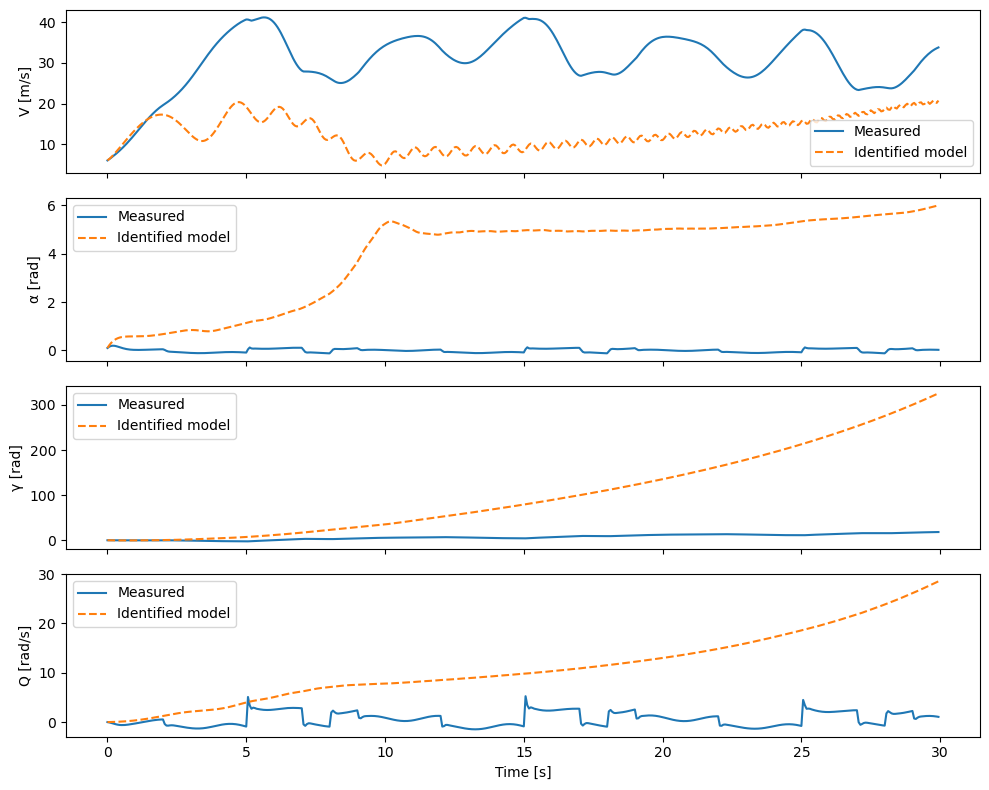

In [61]:
def simulate(t, V0, alpha0, gamma0, Q0, delta_T, delta_e,
             CL0, CL_alpha, CD0, k_CD, CM0, CM_alpha, CM_Q, CM_e):
    from scipy.integrate import solve_ivp

    def dynamics(t_cur, x, u_T, u_e):
        V_, alpha_, gamma_, Q_ = x
        T  = np.interp(t_cur, t, u_T)
        de = np.interp(t_cur, t, u_e)

        CL   = CL0 + CL_alpha * alpha_
        CD   = CD0 + k_CD * CL**2
        qhat_ = cbar * Q_ / (2 * V_)
        CM   = CM0 + CM_alpha * alpha_ + CM_Q * qhat_ + CM_e * de

        qdyn = 0.5 * rho * V_**2
        L    = qdyn * S * CL
        D    = qdyn * S * CD
        M    = qdyn * S * cbar * CM

        Vdot_     = (-D + T*np.cos(alpha_) - m*g*np.sin(gamma_)) / m
        gammadot_ = ( L + T*np.sin(alpha_) - m*g*np.cos(gamma_)) / (m * V_)
        Qdot_     = M / Jy
        alphadot_ = Q_ - gammadot_
        return [Vdot_, alphadot_, gammadot_, Qdot_]

    sol = solve_ivp(dynamics, [t[0], t[-1]], [V0, alpha0, gamma0, Q0],
                    t_eval=t, args=(delta_T, delta_e), method='RK45',
                    rtol=1e-6, atol=1e-8)
    return sol

sol = simulate(t, V[0], alpha[0], gamma[0], Q[0], delta_T, delta_e,
               CL0, CL_alpha, CD0, k_CD, CM0, CM_alpha, CM_Q, CM_e)

fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
labels = ["V [m/s]", "α [rad]", "γ [rad]", "Q [rad/s]"]
for i, (ax, lbl) in enumerate(zip(axes, labels)):
    ax.plot(t, [V, alpha, gamma, Q][i], label="Measured")
    ax.plot(sol.t, sol.y[i], "--", label="Identified model")
    ax.set_ylabel(lbl)
    ax.legend()
plt.xlabel("Time [s]")
plt.tight_layout()
plt.show()

simulate model

make statespace model of system

lets find the frf